In [ ]:
"""
Imports libraries required for data analysis and visualization.
Pandas and NumPy handle data operations, while Matplotlib and Seaborn are used for plotting graphs.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
"""
Loads the spam dataset from a CSV file with latin-1 encoding,
then display the first few rows to preview the data.
"""
df = pd.read_csv("data/spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
"""
Selects only the relevant columns from the dataset and renames them
to clearer names for easier understanding and further processing.
"""
df = df[['v1','v2']]

df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
"""
Converts text labels into numerical values for machine learning.
'ham' becomes 0 and 'spam' becomes 1 so the model can process them.
"""
df['label'] = df['label'].map({'ham':0, 'spam':1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


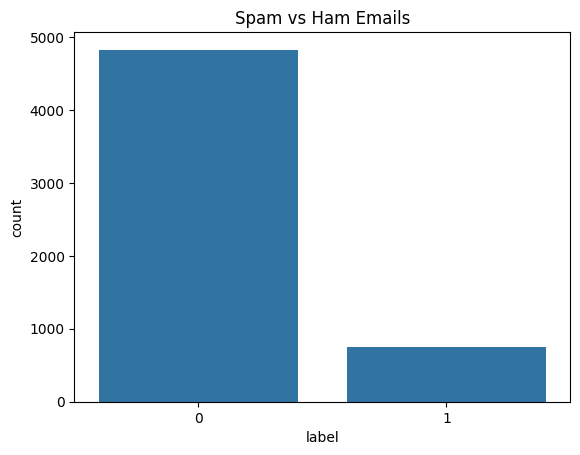

In [ ]:
"""
Visualizes the distribution of spam and ham messages
using a count plot to understand the dataset balance.
"""
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Emails")
plt.show()

In [ ]:
"""
Converts text messages into numerical features using TF-IDF vectorization
so the machine learning model can process the email text.
"""
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['message'])

y = df['label']

In [ ]:
"""
Splits the dataset into training and testing sets so the model can learn from
training data and be evaluated on unseen data.
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
"""
Creates and trains a Naive Bayes classification model to detect spam messages.
The model learns patterns from the training data to classify emails as spam or ham.
"""
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

In [ ]:
"""
Uses the trained model to predict labels for the test dataset
and display the first 10 predicted results.
"""
predictions = model.predict(X_test)

print(predictions[:10])

In [ ]:
"""
Evaluates the model’s performance using accuracy and a classification report
to understand how well it detects spam and ham messages.
"""
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions))

In [ ]:
"""
Tests the trained spam detection model with a new email message.
The text is converted to TF-IDF features and the model predicts whether it is spam or not.
"""
email = ["Congratulations! You won a free prize"]
email_vector = vectorizer.transform(email)

prediction = model.predict(email_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

In [ ]:
"""
Saves the trained spam detection model into a file
so it can be reused later without retraining.
"""
import joblib

joblib.dump(model, "spam_model.pkl")